# 01 - Data Overview & EDA + Evaluation




## 1. Import Libraries.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# For evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

pd.set_option('mode.chained_assignment', None)


## 2. Load Raw Dataset


In [34]:
# Load classification dataset
df_classification = pd.read_csv('data/raw/dirty_cafe_sales.csv')

# Load clustering dataset
df_clustering = pd.read_csv('data/raw/retail_store_sales.csv')


## 3. Dataset Overview - Classification


In [35]:
print("Classification Dataset Shape:", df_classification.shape)
display(df_classification.head())
display(df_classification.info())


Classification Dataset Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


None

## 4. Missing Values Overview


In [36]:
missing_overview = df_classification.isnull().sum()
missing_percent = (missing_overview / len(df_classification)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_overview,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
display(missing_df)


,Missing Count,Percentage
Location,3265,32.65
Payment Method,2579,25.79
Item,333,3.33
Price Per Unit,179,1.79
Total Spent,173,1.73
Transaction Date,159,1.59
Quantity,138,1.38


## 5. Duplicates Overview


In [37]:
duplicate_count = df_classification.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df_classification)) * 100:.2f}%")


Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## 6. Basic Visualizations


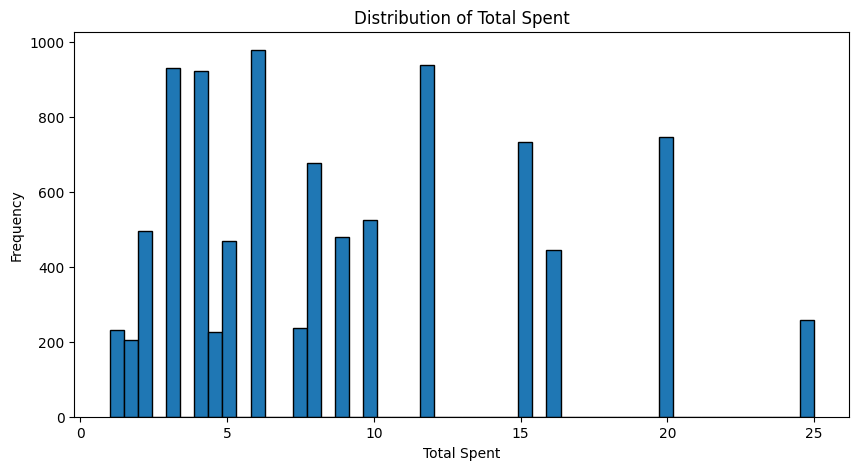

In [38]:
# Visualization 1: Distribution of Total Spent
df_numeric = df_classification.copy()
df_numeric['Total Spent'] = pd.to_numeric(df_numeric['Total Spent'], errors='coerce')
df_numeric = df_numeric.dropna(subset=['Total Spent'])

plt.figure(figsize=(10, 5))
plt.hist(df_numeric['Total Spent'], bins=50, edgecolor='black')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.title('Distribution of Total Spent')
plt.show()


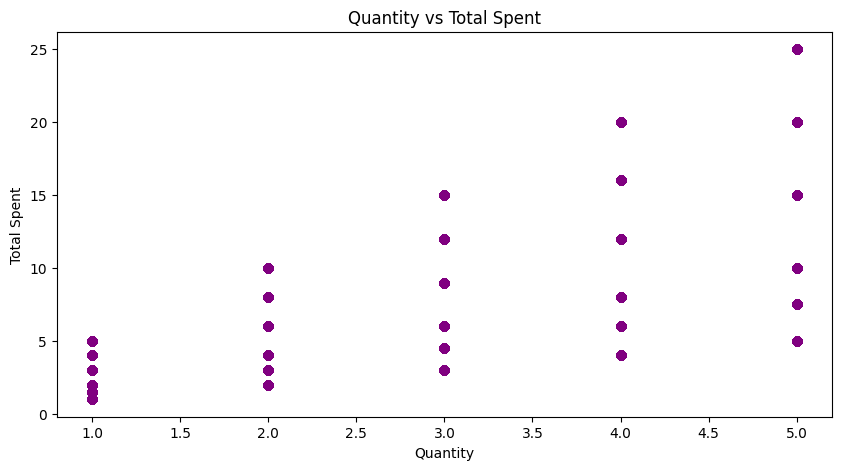

In [39]:
# Visualization 2: Scatter plot - Quantity vs Total Spent
df_numeric['Quantity'] = pd.to_numeric(df_numeric['Quantity'], errors='coerce')
df_numeric = df_numeric.dropna(subset=['Quantity', 'Total Spent'])

plt.figure(figsize=(10, 5))
plt.scatter(df_numeric['Quantity'], df_numeric['Total Spent'], alpha=0.6, color='purple')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.title('Quantity vs Total Spent')
plt.show()


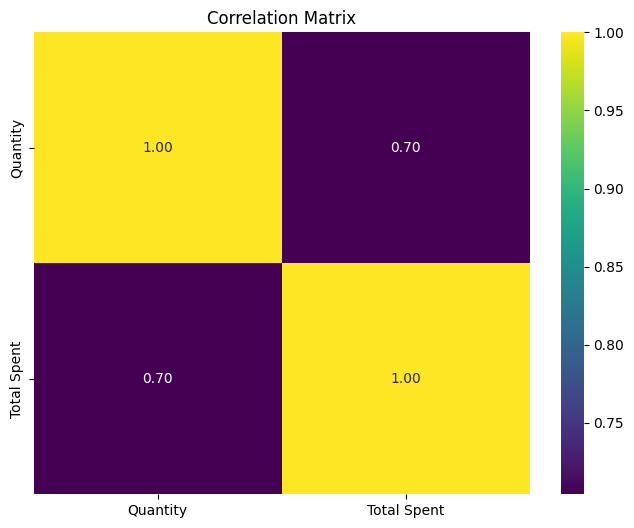

In [40]:
# Visualization 3: Correlation Matrix
numeric_cols = df_numeric.select_dtypes(include=[np.number])
numeric_cols = numeric_cols.dropna()

if not numeric_cols.empty and numeric_cols.shape[1] > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='viridis')
    plt.title('Correlation Matrix')
    plt.show()
else:
    print("Warning: No sufficient numeric columns for correlation matrix.")


## 7. Evaluation - Supervised Models

**Note**: This section evaluates the supervised models after they are trained .
Load the predictions from the trained models and evaluate them.


In [41]:
# Load preprocessed data 
X_test = pd.read_csv('data/processed/X_test_classification.csv')
y_test = pd.read_csv('data/processed/y_test_classification.csv')



# Load model predictions and evaluate

try:
    y_pred_lr = pd.read_csv('data/processed/y_pred_lr.csv').values.flatten()
    y_pred_nb = pd.read_csv('data/processed/y_pred_nb.csv').values.flatten()
    y_pred_dt = pd.read_csv('data/processed/y_pred_dt.csv').values.flatten()
    y_pred_svm = pd.read_csv('data/processed/y_pred_svm.csv').values.flatten()

    # Load predicted probabilities for ROC-AUC
    y_proba_lr = pd.read_csv('data/processed/y_proba_lr.csv').values
    y_proba_nb = pd.read_csv('data/processed/y_proba_nb.csv').values
    y_proba_dt = pd.read_csv('data/processed/y_proba_dt.csv').values
    y_proba_svm = pd.read_csv('data/processed/y_proba_svm.csv').values
    
    y_test = y_test.values.flatten()
    
    models = {
        'Logistic Regression': (y_pred_lr, y_proba_lr),
        'Naive Bayes': (y_pred_nb, y_proba_nb),
        'Decision Tree': (y_pred_dt, y_proba_dt),
        'SVM': (y_pred_svm, y_proba_svm)
    }
    
    # Calculate metrics for each model
    results = []
    for model_name, (y_pred, y_proba) in models.items():
        accuracy_pct = accuracy_score(y_test, y_pred) * 100
        precision_pct = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        recall_pct = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        f1_pct = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

        # Multi-class ROC-AUC using probability estimates
        roc_auc_pct = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted') * 100

        results.append({
            'Model': model_name,
            'Accuracy (%)': round(accuracy_pct, 2),
            'Precision (%)': round(precision_pct, 2),
            'Recall (%)': round(recall_pct, 2),
            'F1-Score (%)': round(f1_pct, 2),
            'ROC-AUC (%)': round(roc_auc_pct, 2)
        })
    
    results_df = pd.DataFrame(results)
    display(results_df)
    
except FileNotFoundError:
    print("Model predictions not found. Please run Person 6's notebook first to generate predictions.")
    print("Expected files:")
    print("- data/processed/y_pred_lr.csv")
    print("- data/processed/y_pred_nb.csv")
    print("- data/processed/y_pred_dt.csv")
    print("- data/processed/y_pred_svm.csv")
    print("- data/processed/y_proba_lr.csv")
    print("- data/processed/y_proba_nb.csv")
    print("- data/processed/y_proba_dt.csv")
    print("- data/processed/y_proba_svm.csv")


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,Logistic Regression,16.86,28.28,16.86,19.34,49.55
1,Naive Bayes,13.34,30.57,13.34,16.55,48.99
2,Decision Tree,26.74,27.13,26.74,26.91,48.77
3,SVM,21.49,28.34,21.49,23.79,50.44


## 8. Confusion Matrix Visualization


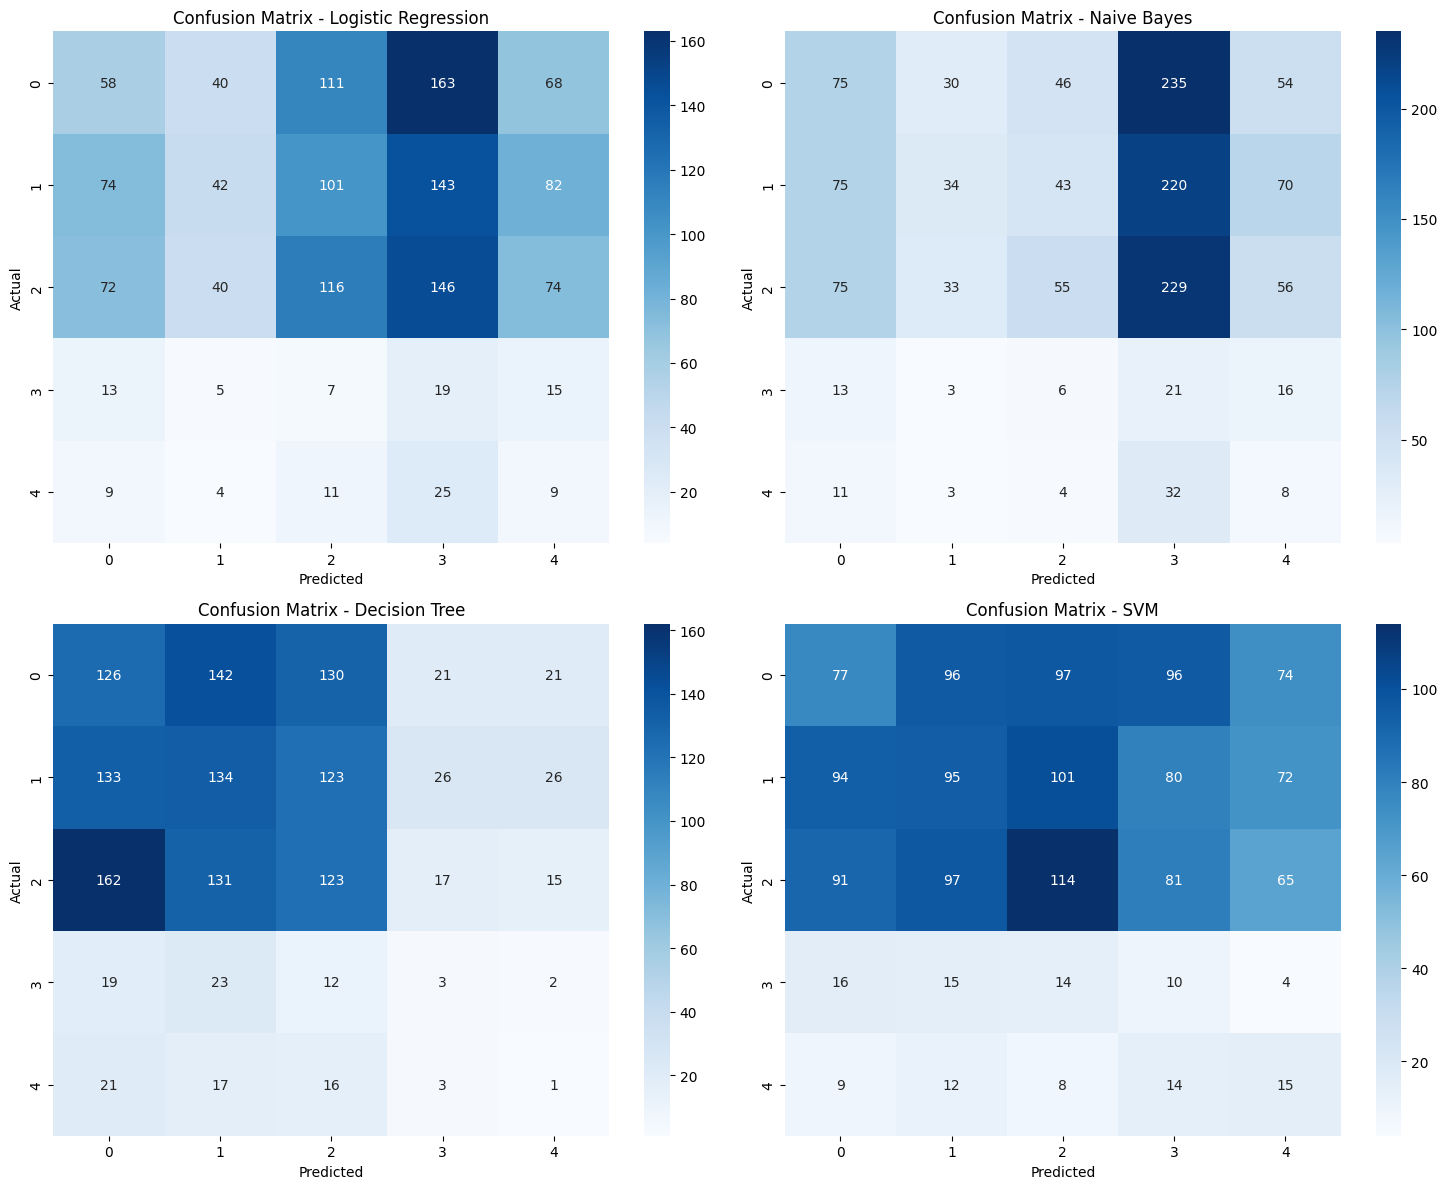

In [42]:
try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, (model_name, (y_pred, _)) in enumerate(models.items()):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'Confusion Matrix - {model_name}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("Models dictionary not found. Please run the evaluation cell above first.")


## 9. Classification Report


In [43]:
try:
    for model_name, (y_pred, _) in models.items():
        print(f"\n{'='*50}")
        print(f"Classification Report - {model_name}")
        print(f"{'='*50}")
        print(classification_report(y_test, y_pred))
        
except NameError:
    print("Models dictionary not found. Please run the evaluation cell above first.")



Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.26      0.13      0.17       440
           1       0.32      0.10      0.15       442
           2       0.34      0.26      0.29       448
           3       0.04      0.32      0.07        59
           4       0.04      0.16      0.06        58

    accuracy                           0.17      1447
   macro avg       0.20      0.19      0.15      1447
weighted avg       0.28      0.17      0.19      1447


Classification Report - Naive Bayes
              precision    recall  f1-score   support

           0       0.30      0.17      0.22       440
           1       0.33      0.08      0.12       442
           2       0.36      0.12      0.18       448
           3       0.03      0.36      0.05        59
           4       0.04      0.14      0.06        58

    accuracy                           0.13      1447
   macro avg       0.21      0.17      0.13      